# Gather the quantitative impact

In [1]:
import datetime as dt
import geopandas as gpd
from matplotlib import pyplot as plt
from src.data import *
from src.post_process_functions import *
from src.hazard_def import *
from src.impact_def import *
from src.accuracy import *

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\lhasbini\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lhasbini\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lhasbini\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
#load data (model)
model = "meta-llama_llama-4-scout-17b-16e-instruct"
#"llama-3.1-8b-instant"
# #"llama-3.3-70b-versatile"
# "meta-llama_llama-4-scout-17b-16e-instruct"
res_savename_ext = f"post_processed_monty_200rep_meta-llama_llama-4-scout-17b-16e-instruct_v190925"
#f"post_processed_monty_200rep_meta-llama_llama-4-scout-17b-16e-instruct_v190925"
#f"post_processed_flags_labelled_reports_{model}_v230925"
#"post_processed_llm_response_impact_labelled_reports_test_multiprompt_continue_v050925_21rep_meta-llama_llama-4-scout-17b-16e-instruct"
#"post_processed_labelled_reports_test_date_meta-llama_llama-4-scout-17b-16e-instruct_v180925"
extracted_df_no_geo = pd.read_csv(DATA_OUT_PROC / (res_savename_ext+".csv"))

split_lowest = True
suffix = "_geo_split_lowest" if split_lowest else "_geo"
suffix2 ="_v260925"
#load geocoded data
extracted_df = gpd.read_file(DATA_OUT_PROC / (res_savename_ext+suffix+suffix2+".gpkg"))#(res_savename_ext+suffix+suffix2+".gpkg")

In [11]:
extracted_df.head()

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,country,location,locationAnnotation,...,country_iso3_kw,unit_type,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code,impactValueApprox,geometry
0,Affected People,7500000.0,NaN,NaN,exact,people,['These two hurricanes affected more than7.5 m...,"['Guatemala', 'Honduras', 'Nicaragua']",[],['These two hurricanes affected more than7.5 m...,...,PAN,other,ADM_0,0,0,"['Guatemala', 'Nicaragua', 'Honduras']","['Guatemala', 'Nicaragua', 'Honduras']","['GTM', 'NIC', 'HND']",NaN,"MULTIPOLYGON (((-87.62558 13.28992, -87.62209 ..."
1,Affected People,5000000.0,NaN,NaN,exact,people,['These departments are home to some five mill...,['Guatemala'],"['Alta Verapaz', 'Izabal', 'Quiché', 'Huehuete...",['These departments are home to some five mill...,...,PAN,other,ADM_1,0,0,"['Alta Verapaz', 'Izabal', 'Quiché', 'Huehuete...","['Alta Verapaz', 'Izabal', 'Quiché', 'Huehuete...",['GTM'],NaN,"MULTIPOLYGON (((-89.35679 14.42262, -89.35685 ..."
2,Affected People,4700000.0,NaN,NaN,exact,people,['Approximately4.7 million people5 were affect...,['Honduras'],"['Sula Valley', 'Copán', 'Choluteca', 'Comayag...",['Hurricane Iota affected communities in the S...,...,PAN,other,ADM_0,3,1,"['Guatemala', 'Copán', 'Choluteca', 'Cortés', ...","['Guatemala', 'Honduras', 'Guatemala', 'Guatem...","['GTM', 'HND']",NaN,"MULTIPOLYGON (((-87.61326 13.2833, -87.6151 13..."
3,Affected People,NaN,NaN,NaN,exact,None,['Approximately4.7 million people5 were affect...,['Honduras'],"['Sula Valley', 'Copán', 'Choluteca', 'Comayag...",['Hurricane Iota affected communities in the S...,...,PAN,other,ADM_1,0,1,"['Copán', 'Choluteca', 'Cortés', 'Atlántida', ...","['Copán', 'Guatemala', 'Quiché', 'Suchitepéque...","['HND', 'GTM']",NaN,"MULTIPOLYGON (((-88.81259 15.26273, -88.75929 ..."
4,Affected People,NaN,NaN,NaN,exact,None,['Approximately4.7 million people5 were affect...,['Honduras'],"['Sula Valley', 'Copán', 'Choluteca', 'Comayag...",['Hurricane Iota affected communities in the S...,...,PAN,other,ADM_2,0,1,"['Choluteca', 'Atlántida', 'Colón']","['Guatemala', 'Quiché', 'El Palmar']",['GTM'],NaN,"MULTIPOLYGON (((-90.83723 16.79571, -90.83745 ..."


In [3]:
extracted_df_copy = extracted_df.copy()

In [4]:
def union_lists(series):
    """Merge lists or single strings into a unique flat list."""
    all_items = []
    for x in series:
        if isinstance(x, list):
            all_items.extend(x)
        elif pd.notna(x):
            all_items.append(x)
    return list(set(all_items)) if all_items else np.nan

In [5]:
# Split qualitative (no numeric info) and quantitative (has at least one numeric)
mask_quant = extracted_df_copy[['impactValue', 'impactValueMin', 'impactValueMax']].notna().any(axis=1)
df_quant = extracted_df_copy[mask_quant].copy()
df_qual = extracted_df_copy[~mask_quant].copy()

In [6]:
# Group qualitative rows by impactSubtype and locationLowestAdmin
df_qual_grouped = (
    df_qual.groupby(['appealCode', 'impactSubtype', 'locationLowestAdmin'], dropna=False)
    .agg({
        'impactValue': 'first',
        'impactValueMin': 'first',
        'impactValueMax': 'first',
        'impactValuePrecision': 'first',
        'impactUnit': 'first',
        'valueAnnotation': union_lists,
        'country': union_lists,
        'location': union_lists,
        'locationAnnotation': union_lists,
        'country_iso3_kw': union_lists,
        'unit_type': 'first',
        'geocoding_country_flag': 'max',
        'geocoding_osm_flag': 'max',
        'locationOsm': union_lists,
        'locationPolygon': union_lists,
        'iso3_code': union_lists,
        'impactValueApprox': 'first',
        'geometry': 'first',
    })
    .reset_index()
)

In [8]:
count_grouped = df_qual_grouped['appealCode'].value_counts().sort_index()
count_raw = df_qual['appealCode'].value_counts().sort_index()

count_grouped, count_raw = count_grouped.align(count_raw, fill_value=0)

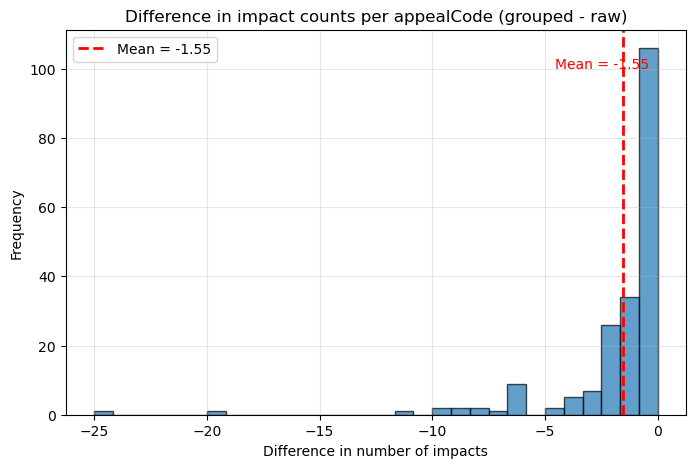

In [ ]:
diff_counts = count_grouped - count_raw

# Compute mean difference
mean_diff = diff_counts.mean()

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(diff_counts, bins=30, edgecolor='k', alpha=0.7)
plt.axvline(mean_diff, color='red', linestyle='--', linewidth=2, label=f"Mean = {mean_diff:.2f}")
plt.title("Difference in impact counts per appealCode (grouped - raw)")
plt.xlabel("Difference in number of impacts")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)

# Add text annotation
# plt.text(mean_diff-, plt.ylim()[1]*0.9, f"Mean = {mean_diff:.2f}", color='red', ha='left')

plt.show()

In [7]:
df_qual_grouped.head()

,appealCode,impactSubtype,locationLowestAdmin,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,country,...,locationAnnotation,country_iso3_kw,unit_type,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code,impactValueApprox,geometry
0,MDR43007,Access to Education,ADM_0,NaN,NaN,NaN,None,None,[['These communities reported that damage not ...,"[['Guatemala', 'Honduras', 'Nicaragua']]",...,[['These communities reported that damage not ...,[PAN],other,10,1,"[['Alta Verapaz', 'Izabal', 'Quiché', 'Huehuet...","[['Guatemala', 'Guatemala', 'Guatemala', 'Guat...","[['GTM', 'HND']]",NaN,"MULTIPOLYGON (((-88.2279 15.72198, -88.22718 1..."
1,MDR43007,Access to Education,ADM_1,NaN,NaN,NaN,None,None,[['These communities reported that damage not ...,"[['Guatemala', 'Honduras', 'Nicaragua']]",...,[['These communities reported that damage not ...,[PAN],other,0,1,"[['Alta Verapaz', 'Izabal', 'Quiché', 'Huehuet...","[['Alta Verapaz', 'Izabal', 'Quiché', 'Huehuet...","[['GTM', 'HND']]",NaN,"MULTIPOLYGON (((-89.14855 14.67621, -89.14856 ..."
2,MDR43007,Access to Education,ADM_2,NaN,NaN,NaN,None,None,[['These communities reported that damage not ...,"[['Guatemala', 'Honduras', 'Nicaragua']]",...,[['These communities reported that damage not ...,[PAN],other,0,1,"[['Choluteca', 'Atlántida', 'Colón', 'Managuá'...","[['Guatemala', 'Quiché', 'El Palmar', 'Izabal'...",[['GTM']],NaN,"MULTIPOLYGON (((-89.15429 15.0688, -89.15401 1..."
3,MDR43007,Access to Food,ADM_0,NaN,NaN,NaN,None,None,[['The breaches to riverbank walls have led to...,[['Honduras']],...,[['Hurricane Iota affected communities in the ...,[PAN],other,3,1,"[['Guatemala', 'Copán', 'Choluteca', 'Cortés',...","[['Guatemala', 'Honduras', 'Guatemala', 'Guate...","[['GTM', 'HND']]",NaN,"MULTIPOLYGON (((-87.61326 13.2833, -87.6151 13..."
4,MDR43007,Access to Food,ADM_1,NaN,NaN,NaN,None,None,[['The breaches to riverbank walls have led to...,[['Honduras']],...,[['Hurricane Iota affected communities in the ...,[PAN],other,0,1,"[['Copán', 'Choluteca', 'Cortés', 'Atlántida',...","[['Copán', 'Guatemala', 'Quiché', 'Suchitepéqu...","[['HND', 'GTM']]",NaN,"MULTIPOLYGON (((-88.81259 15.26273, -88.75929 ..."


In [35]:
df_qual_grouped.loc[df_qual_grouped["appealCode"]=="MDRAF009"]["impactSubtype"].value_counts()

impactSubtype
Access to Education                              2
Access to Food                                   2
Access to Power and Energy                       2
Other Human Impacts                              2
Mobility and Access to Transport                 2
Missing People                                   2
Human Health and Wellbeing                       2
Water, Sanitation, and Hygiene Infrastructure    2
Agricultural Infrastructure                      1
Affected People                                  1
Access to Healthcare                             1
Crop Production and Forestry                     1
Human Deaths                                     1
Other Infrastructural Impacts                    1
Road Infrastructure                              1
Name: count, dtype: int64

In [37]:
len(df_qual_grouped.loc[df_qual_grouped["appealCode"]=="MDRAF009"])

23

In [38]:
df_qual.loc[df_qual["appealCode"]=="MDRAF009"]["impactSubtype"].value_counts()

impactSubtype
Other Infrastructural Impacts                    2
Water, Sanitation, and Hygiene Infrastructure    2
Missing People                                   2
Mobility and Access to Transport                 2
Access to Food                                   2
Other Human Impacts                              2
Access to Power and Energy                       2
Access to Education                              2
Human Health and Wellbeing                       2
Crop Production and Forestry                     1
Human Deaths                                     1
Affected People                                  1
Agricultural Infrastructure                      1
Road Infrastructure                              1
Access to Healthcare                             1
Name: count, dtype: int64

In [39]:
len(df_qual.loc[df_qual["appealCode"]=="MDRAF009"])

24

In [29]:
df_qual['appealCode'].unique()

array(['MDR43007', 'MDR49009', 'MDR55001', 'MDRAF007', 'MDRAF008',
       'MDRAF009', 'MDRAF010', 'MDRAF011', 'MDRAF012', 'MDRAF014',
       'MDRAF015', 'MDRAG003', 'MDRAL006', 'MDRAL007', 'MDRAL008',
       'MDRAM003', 'MDRAM004', 'MDRAM005', 'MDRAM006', 'MDRAM011',
       'MDRAM013', 'MDRAO007', 'MDRAO008', 'MDRAO011', 'MDRAR010',
       'MDRAR011', 'MDRAR012', 'MDRAR013', 'MDRAR014', 'MDRAR015',
       'MDRAR016', 'MDRAR017', 'MDRAR019', 'MDRAR020', 'MDRAR021',
       'MDRAR023', 'MDRAR024', 'MDRBA012', 'MDRBA013', 'MDRBA014',
       'MDRBA015', 'MDRBA017', 'MDRBD016', 'MDRBD017', 'MDRBD019',
       'MDRBD020', 'MDRBD022', 'MDRBD023', 'MDRBD024', 'MDRBD025',
       'MDRBD027', 'MDRBD028', 'MDRBD030', 'MDRBD034', 'MDRBD035',
       'MDRBD036', 'MDRBF013', 'MDRBF015', 'MDRBF019', 'MDRBG003',
       'MDRBI014', 'MDRBI016', 'MDRBI018', 'MDRBI020', 'MDRBJ008',
       'MDRBJ016', 'MDRBJ017', 'MDRBJ019', 'MDRBJ021', 'MDRBO012',
       'MDRBO013', 'MDRBO015', 'MDRBO016', 'MDRBO017', 'MDRBO0

In [43]:
df_qual.loc[df_qual["appealCode"]=="MDRCF029"][['appealCode', 'impactSubtype', 'locationLowestAdmin']].iloc[:50]

,appealCode,impactSubtype,locationLowestAdmin
3330,MDRCF029,Affected People,ADM_1
3331,MDRCF029,Affected People,ADM_2
3333,MDRCF029,Injured People,ADM_1
3334,MDRCF029,Injured People,ADM_2
3337,MDRCF029,Displaced People,ADM_1
3338,MDRCF029,Displaced People,ADM_2
3340,MDRCF029,Homeless People,ADM_1
3341,MDRCF029,Homeless People,ADM_2
3343,MDRCF029,Residential Buildings,ADM_1
3344,MDRCF029,Residential Buildings,ADM_2


In [44]:
df_qual.loc[df_qual["appealCode"]=="MDRCF029"].iloc[:15]

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,country,location,locationAnnotation,...,country_iso3_kw,unit_type,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code,impactValueApprox,geometry
3330,Affected People,NaN,NaN,NaN,exact,None,"['There were24,758 people aﬀected by the ﬂoods:']",['Central African Republic'],"['Bangui', 'Ouaka', 'Ouham-Pendé', 'Arrondisse...","['There were24,758 people aﬀected by the ﬂoods...",...,CAF,other,ADM_1,0,0,"['Kouango', 'Paoua', 'Bangui', 'Bimbo', 'Ouaka...","['Ouaka', 'Ouham-Pendé', ""Ombella-M'Poko"", 'Lo...",['CAF'],NaN,"MULTIPOLYGON (((18.59781 3.88053, 18.59705 3.8..."
3331,Affected People,NaN,NaN,NaN,exact,None,"['There were24,758 people aﬀected by the ﬂoods:']",['Central African Republic'],"['Bangui', 'Ouaka', 'Ouham-Pendé', 'Arrondisse...","['There were24,758 people aﬀected by the ﬂoods...",...,CAF,other,ADM_2,0,0,"['Kouango', 'Paoua', 'Bangui', 'Bimbo', 'Bégou...","['Kouango', 'Paoua', 'Bangui', 'Bimbo', ""Ombel...",['CAF'],NaN,"MULTIPOLYGON (((18.82143 4.55963, 18.81957 4.5..."
3333,Injured People,NaN,NaN,NaN,exact,None,"['There were24,758 people aﬀected by the ﬂoods...",['Central African Republic'],"['Bangui', 'Arrondissement2', 'Arrondissement3...","['There were24,758 people aﬀected by the ﬂoods...",...,CAF,other,ADM_1,0,0,"['Kouango', 'Paoua', 'Bangui', 'Bimbo', 'Bégou...","['Ouaka', 'Ouham-Pendé', ""Ombella-M'Poko"", 'Lo...",['CAF'],NaN,"MULTIPOLYGON (((18.59679 3.89035, 18.59781 3.8..."
3334,Injured People,NaN,NaN,NaN,exact,None,"['There were24,758 people aﬀected by the ﬂoods...",['Central African Republic'],"['Bangui', 'Arrondissement2', 'Arrondissement3...","['There were24,758 people aﬀected by the ﬂoods...",...,CAF,other,ADM_2,0,0,"['Kouango', 'Paoua', 'Bangui', 'Bimbo', 'Bégou...","['Kouango', 'Paoua', 'Bangui', 'Bimbo', ""Ombel...",['CAF'],NaN,"MULTIPOLYGON (((18.82143 4.55963, 18.81957 4.5..."
3337,Displaced People,NaN,NaN,NaN,exact,None,"['There were24,758 people aﬀected by the ﬂoods...",['Central African Republic'],"['Bangui', 'Ouaka', 'Ouham-Pendé', 'Arrondisse...","['The towns of Paoua, Kouango and Bambari were...",...,CAF,other,ADM_1,0,0,"['Kouango', 'Paoua', 'Bangui', 'Bimbo', 'Ouaka...","['Ouaka', 'Ouham-Pendé', ""Ombella-M'Poko"", 'Lo...",['CAF'],NaN,"MULTIPOLYGON (((18.59781 3.88053, 18.59705 3.8..."
3338,Displaced People,NaN,NaN,NaN,exact,None,"['There were24,758 people aﬀected by the ﬂoods...",['Central African Republic'],"['Bangui', 'Ouaka', 'Ouham-Pendé', 'Arrondisse...","['The towns of Paoua, Kouango and Bambari were...",...,CAF,other,ADM_2,0,0,"['Kouango', 'Paoua', 'Bangui', 'Bimbo', 'Bégou...","['Kouango', 'Paoua', 'Bangui', 'Bimbo', ""Ombel...",['CAF'],NaN,"MULTIPOLYGON (((18.82143 4.55963, 18.81957 4.5..."
3340,Homeless People,NaN,NaN,NaN,exact,None,"['There were24,758 people aﬀected by the ﬂoods...",['Central African Republic'],"['Bangui', 'Ouaka', 'Ouham-Pendé', 'Arrondisse...","['The towns of Paoua, Kouango and Bambari were...",...,CAF,other,ADM_1,0,0,"['Kouango', 'Paoua', 'Bangui', 'Bimbo', 'Ouaka...","['Ouaka', 'Ouham-Pendé', ""Ombella-M'Poko"", 'Lo...",['CAF'],NaN,"MULTIPOLYGON (((18.59781 3.88053, 18.59705 3.8..."
3341,Homeless People,NaN,NaN,NaN,exact,None,"['There were24,758 people aﬀected by the ﬂoods...",['Central African Republic'],"['Bangui', 'Ouaka', 'Ouham-Pendé', 'Arrondisse...","['The towns of Paoua, Kouango and Bambari were...",...,CAF,other,ADM_2,0,0,"['Kouango', 'Paoua', 'Bangui', 'Bimbo', 'Bégou...","['Kouango', 'Paoua', 'Bangui', 'Bimbo', ""Ombel...",['CAF'],NaN,"MULTIPOLYGON (((18.82143 4.55963, 18.81957 4.5..."
3343,Residential Buildings,NaN,NaN,NaN,exact,None,"['There were24,758 people aﬀected by the ﬂoods...",['Central African Republic'],"['Arrondissement2,3,4,5,6,8, Begoua, Bimbo', '...","['The towns of Paoua, Kouango and Bambari were...",...,CAF,other,ADM_1,0,0,"['Kouango', 'Paoua', 'Bangui', 'Bambari']","['Ouaka', 'Ouham-P

In [ ]:
# Group per appealCode and impact subtype 